# Aplicación del modelo sobre `catalog`

Usa el modelo ya seleccionado y exportado en `2A_Evaluacion_seleccion_modelo.ipynb` (Random Forest, entrenado sobre `department` y `process_name` con **Ordinal Encoding**) para puntuar los procesos de `process_catalog.csv`, que no tienen `implementation_success` conocido.

**Pasos**
1. Carga de datos y del modelo
2. Transformación de `catalog` — igual que la de `historical` en el notebook de entrenamiento: `log_annual_hours` y Ordinal Encoding de `department`/`process_name`
3. Predicción de `implementation_success` y `success_probability`
4. Cálculo de `priority_score`
5. Exportación del resultado

## 1. Carga de datos y del modelo

In [3]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)

PATH_HIST = "../data/outputs/1A_historical_ai_projects.csv"       # mismos datos usados para entrenar el modelo
PATH_CATALOG = "../data/outputs/1A_process_catalog.csv"
PATH_MODELO = "../models/modelo_implementation_success.joblib"
RUTA_SALIDA = Path("../data/outputs/2B_catalog_priorizado.csv")

TARGET = "implementation_success"
CAT_COLS = ["department", "process_name"]

In [4]:
historical = pd.read_csv(PATH_HIST)
catalog = pd.read_csv(PATH_CATALOG)
modelo = joblib.load(PATH_MODELO)

print(f"historical: {historical.shape[0]} filas | catalog: {catalog.shape[0]} filas")
print("Columnas que espera el modelo, en orden:")
print(list(modelo.feature_names_in_))
catalog.head()

historical: 160 filas | catalog: 300 filas
Columnas que espera el modelo, en orden:
['department', 'process_name', 'monthly_volume', 'avg_minutes', 'manual_share', 'data_availability', 'process_complexity', 'annual_hours', 'automation_potential', 'recoverable_hours', 'estimated_annual_benefit', 'feasibility_score', 'log_annual_hours']


,process_id,department,process_name,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score
0,P0001,IT,Invoice validation,252,31.4,0.537,3,5,1582.56,0.4485,709.78,21293345.0,0.36
1,P0002,Sales,Invoice validation,256,59.6,0.798,2,5,3051.52,0.5190,1583.74,47512166.0,0.24
2,P0003,Human Resources,Customer data entry,425,14.0,0.696,3,2,1190.00,0.6480,771.12,23133600.0,0.60
3,P0004,IT,Data consolidation,90,33.5,0.947,4,3,603.00,0.7935,478.48,14354415.0,0.64
4,P0005,Customer Service,Monthly reporting,703,32.5,0.621,3,5,4569.50,0.4905,2241.34,67240192.0,0.36


## 2. Transformación de `catalog`

`catalog` ya trae las variables derivadas del EDA (`annual_hours`, `automation_potential`, `recoverable_hours`, `estimated_annual_benefit`, `feasibility_score`), así que solo faltan las dos transformaciones que documenta el notebook de entrenamiento:

- `log_annual_hours = log1p(annual_hours)`
- `department` y `process_name` codificados con `OrdinalEncoder`

In [5]:
catalog_encoder = OrdinalEncoder()
catalog_encoder.fit(historical[CAT_COLS])   # se ajusta sobre historical, igual que en el entrenamiento

catalog_transformado = catalog.copy()
catalog_transformado[CAT_COLS] = catalog_encoder.transform(catalog[CAT_COLS])
catalog_transformado["log_annual_hours"] = np.log1p(catalog_transformado["annual_hours"])

catalog_transformado[modelo.feature_names_in_].head()

,department,process_name,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score,log_annual_hours
0,3.0,10.0,252,31.4,0.537,3,5,1582.56,0.4485,709.78,21293345.0,0.36,7.367431
1,7.0,10.0,256,59.6,0.798,2,5,3051.52,0.5190,1583.74,47512166.0,0.24,8.023723
2,2.0,4.0,425,14.0,0.696,3,2,1190.00,0.6480,771.12,23133600.0,0.60,7.082549
3,3.0,6.0,90,33.5,0.947,4,3,603.00,0.7935,478.48,14354415.0,0.64,6.403574
4,0.0,11.0,703,32.5,0.621,3,5,4569.50,0.4905,2241.34,67240192.0,0.36,8.427378


## 3. Predicción

`implementation_success` es la predicción binaria del modelo (umbral 0,5). `success_probability` es `predict_proba` para la clase "éxito" — es la que se usa después en `priority_score`, porque conserva más información que la etiqueta binaria.

In [13]:
X_catalog = catalog_transformado[modelo.feature_names_in_]

catalog["implementation_success"] = modelo.predict(X_catalog)
catalog["success_probability"] = modelo.predict_proba(X_catalog)[:, 1].round(3)

print(f"Procesos predichos como éxito: {catalog['implementation_success'].sum()} de {len(catalog)}")
catalog[["process_id", "department", "process_name", "implementation_success", "success_probability"]].head()

Procesos predichos como éxito: 93 de 300


,process_id,department,process_name,implementation_success,success_probability
0,P0001,IT,Invoice validation,0,0.393
1,P0002,Sales,Invoice validation,0,0.426
2,P0003,Human Resources,Customer data entry,0,0.408
3,P0004,IT,Data consolidation,1,0.587
4,P0005,Customer Service,Monthly reporting,0,0.393


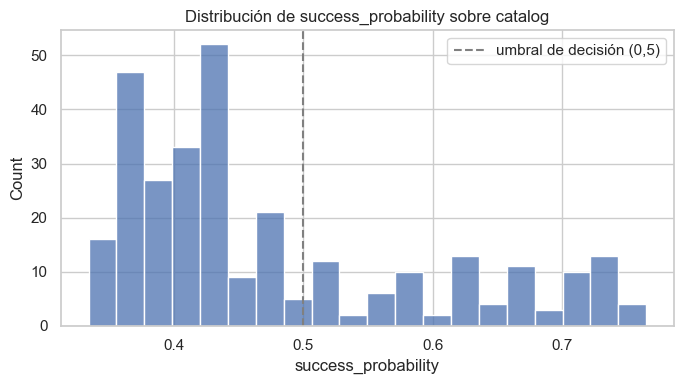

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(catalog["success_probability"], bins=20, color="#4C72B0", ax=ax)
ax.axvline(0.5, color="gray", linestyle="--", label="umbral de decisión (0,5)")
ax.set_title("Distribución de success_probability sobre catalog")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Cálculo de `priority_score`

$$\text{priority\_score} = 0.30 \times \text{normalized\_estimated\_annual\_benefit} + 0.70 \times \text{success\_probability}$$

`success_probability` ya está entre 0 y 1. `estimated_annual_benefit` no — para poder combinarla en el mismo promedio ponderado se normaliza primero con **min-max sobre los procesos de `catalog`**, de forma que el proceso con menor beneficio estimado quede en 0, el de mayor beneficio en 1, y el resto en proporción. Esta es una decisión razonable dado que la fórmula no especifica el método de normalización; con otro método (por ejemplo, normalizar contra `historical` en vez de contra `catalog`) los valores de `priority_score` cambiarían.

In [15]:
beneficio = catalog["estimated_annual_benefit"]
catalog["normalized_estimated_annual_benefit"] = (
    (beneficio - beneficio.min()) / (beneficio.max() - beneficio.min())
).round(3)

catalog["priority_score"] = (
    0.30 * catalog["normalized_estimated_annual_benefit"]
    + 0.70 * catalog["success_probability"]
).round(3)

catalog[["process_id", "estimated_annual_benefit", "normalized_estimated_annual_benefit",
         "success_probability", "priority_score"]].describe().round(3)

,estimated_annual_benefit,normalized_estimated_annual_benefit,success_probability,priority_score
count,3.000000e+02,300.000,300.000,300.000
mean,4.667326e+07,0.099,0.477,0.364
std,6.173550e+07,0.132,0.119,0.099
min,4.186510e+05,0.000,0.334,0.234
25%,1.167913e+07,0.024,0.393,0.288
50%,2.350647e+07,0.049,0.434,0.336
75%,5.681408e+07,0.120,0.555,0.421
max,4.679734e+08,1.000,0.765,0.774


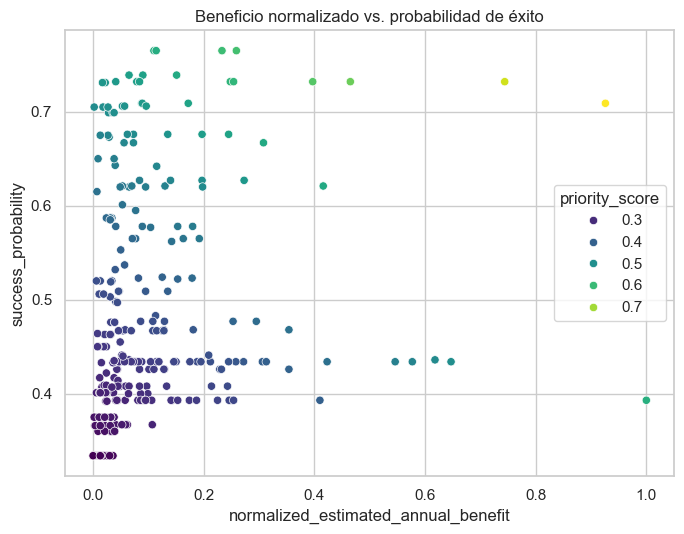

In [16]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=catalog, x="normalized_estimated_annual_benefit", y="success_probability",
                 hue="priority_score", palette="viridis", ax=ax)
ax.set_title("Beneficio normalizado vs. probabilidad de éxito")
plt.tight_layout()
plt.show()

### Los 10 procesos con mayor `priority_score`

In [17]:
top10 = catalog.sort_values("priority_score", ascending=False).head(10)
top10[["process_id", "department", "process_name", "success_probability",
       "normalized_estimated_annual_benefit", "priority_score"]]

,process_id,department,process_name,success_probability,normalized_estimated_annual_benefit,priority_score
25,P0026,Procurement,Email request processing,0.709,0.926,0.774
216,P0217,Sales,Ticket classification,0.732,0.744,0.736
38,P0039,Finance,Inventory update,0.732,0.465,0.652
85,P0086,Customer Service,Ticket classification,0.732,0.397,0.632
181,P0182,IT,Customer data entry,0.765,0.259,0.613
223,P0224,Sales,Customer onboarding,0.765,0.233,0.605
243,P0244,Finance,Data consolidation,0.732,0.254,0.589
208,P0209,Procurement,Purchase order processing,0.732,0.248,0.587
286,P0287,Finance,Account reconciliation,0.393,1.000,0.575
122,P0123,Operations,Invoice validation,0.765,0.114,0.570


## 5. Exportación

Se guarda `catalog` completo: todas sus columnas originales, sin transformar (`department` y `process_name` en texto, no codificados), más las columnas nuevas — `implementation_success` (predicho), `success_probability`, `normalized_estimated_annual_benefit` y `priority_score` — ordenado de mayor a menor prioridad.

In [18]:
catalog_final = catalog.sort_values("priority_score", ascending=False).reset_index(drop=True)

assert not catalog_final.isna().any().any(), "hay valores nulos en el resultado"
assert catalog_final["success_probability"].between(0, 1).all()
assert catalog_final["normalized_estimated_annual_benefit"].between(0, 1).all()
assert catalog_final["implementation_success"].isin([0, 1]).all()

catalog_final.to_csv(RUTA_SALIDA, index=False)
print(f"Guardado: {RUTA_SALIDA.resolve()} ({len(catalog_final)} filas, {catalog_final.shape[1]} columnas)")
catalog_final.head()

Guardado: C:\Users\ascal\Documents\Pruebas Técnicas\prueba_tecnica-ServiceLab\data\outputs\2B_catalog_priorizado.csv (300 filas, 17 columnas)


,process_id,department,process_name,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score,implementation_success,success_probability,normalized_estimated_annual_benefit,priority_score
0,P0026,Procurement,Email request processing,2161,42.5,0.813,5,3,18368.50,0.7865,14446.83,433404758.0,0.76,1,0.709,0.926,0.774
1,P0217,Sales,Ticket classification,2206,31.8,0.734,5,1,14030.16,0.8270,11602.94,348088270.0,0.92,1,0.732,0.744,0.736
2,P0039,Finance,Inventory update,469,95.1,0.709,5,1,8920.38,0.8145,7265.65,217969485.0,0.92,1,0.732,0.465,0.652
3,P0086,Customer Service,Ticket classification,978,42.4,0.695,4,1,8293.44,0.7475,6199.35,185980392.0,0.80,1,0.732,0.397,0.632
4,P0182,IT,Customer data entry,430,58.1,0.779,5,2,4996.60,0.8095,4044.75,121342431.0,0.84,1,0.765,0.259,0.613
